In [1]:
import random
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms

Deciding the randomness values and creating a variable cell from where all the hyper parameters can be changed plus the basic setting of preambles.

In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

CANVAS_SIZE = 224
FASHION_SIZE = 28

GRID_SIZE = 7
NUM_CLASSES = 10

OUTPUT_SIZE = 5 + NUM_CLASSES
TRAIN_SAMPLES = 10000
VAL_SAMPLES = 2000

MIN_OBJECTS = 2
MAX_OBJECTS = 4

BATCH_SIZE = 32
EPOCHS = 15
LEARNING_RATE = 0.001

BOX_LOSS_WEIGHT = 5.0
CLASS_LOSS_WEIGHT = 1.0

OBJECTNESS_THRESHOLD = 0.5
DETECTION_CONFIDENCE_THRESHOLD = 0.35
IOU_THRESHOLD = 0.5

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", DEVICE)
print("Canvas:", CANVAS_SIZE, "x", CANVAS_SIZE)
print("Grid:", GRID_SIZE, "x", GRID_SIZE)
print("Output per cell:", OUTPUT_SIZE)

Device: cuda
Canvas: 224 x 224
Grid: 7 x 7
Output per cell: 15


In [42]:
CLASS_NAMES = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]


converting all the images into python tensors in grayscale + also doing the same for the test images 

the two were seperately generated from the same dataset so that we have more images to work with and different sets of data(sort of a random pnc) 

In [4]:
transform = transforms.ToTensor()

fashion_train = datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

fashion_test = datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

print("Training samples:", len(fashion_train))
print("Test samples:", len(fashion_test))

100%|██████████| 26.4M/26.4M [00:01<00:00, 22.8MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 345kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 6.26MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 15.4MB/s]

Training samples: 60000
Test samples: 10000


checking the dataset and how its loading

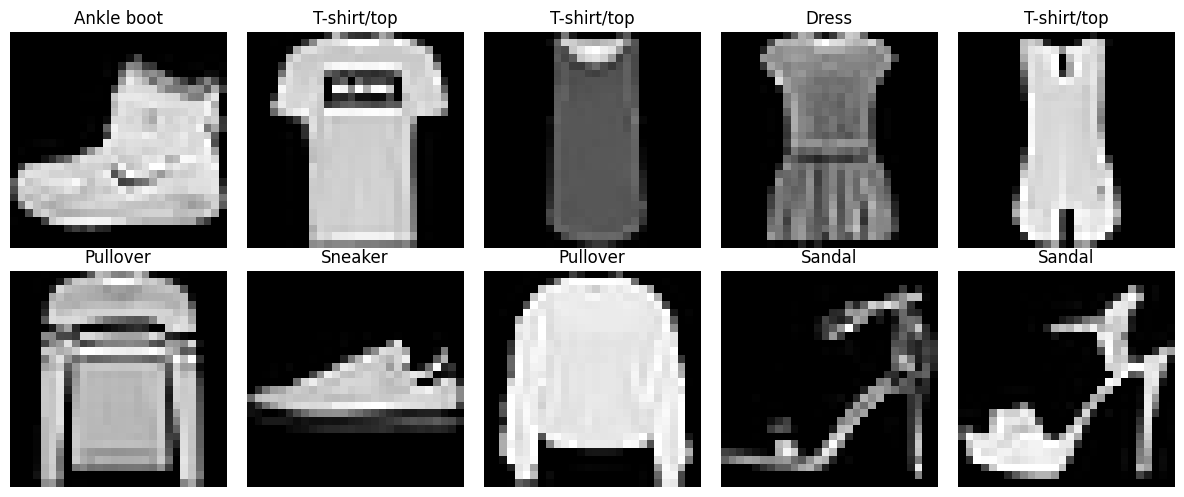

In [5]:
fig, axes = plt.subplots(
    2, 5,
    figsize=(12, 5)
)
for i, ax in enumerate(axes.flat):
    image, label = fashion_train[i]
    
    ax.imshow(image.squeeze(0), cmap="gray")
    ax.set_title(f"{CLASS_NAMES[label]}")
    ax.axis("off")

plt.tight_layout()
plt.show()

converting the tensors to numpy images beacuse we need to resize them to place them on the canvas and the tensors are needed so that we can feed it into the neural network, but the numpy images are for the canvas we are creating

In [7]:
def fashion_tensor_to_numpy(image_tensor):
    image = image_tensor.squeeze(0).numpy()
    image = (
        image * 255
    ).astype(np.uint8)
    return image

takes the real bounding box and the model's predicted bounding box, finds their overlap, compares that overlap to the total area covered by both boxes, and returns a number from 0 to 1 telling us how accurately the object was localized.

In [8]:
def calculate_iou(box_a, box_b):

    ax1, ay1, ax2, ay2 = box_a
    bx1, by1, bx2, by2 = box_b
    ix1 = max(ax1, bx1)
    iy1 = max(ay1, by1)
    ix2 = min(ax2, bx2)
    iy2 = min(ay2, by2)

    intersection_width = max( 0,ix2 - ix1)
    intersection_height = max( 0,iy2 - iy1)
    
    intersection_area = (intersection_width * intersection_height)
    
    area_a = (max(0, ax2 - ax1)* max(0, ay2 - ay1))
    area_b = (max(0, bx2 - bx1)* max(0, by2 - by1))
    
    union_area = (area_a + area_b - intersection_area)
    
    if union_area <= 0:
        return 0.0

    return (intersection_area/ union_area)

the main function that generates a synthetic canvas that is of the size 224x224 and has like a 7x7 grid over it and the images are randomly placed over this canvas

In [9]:
def generate_synthetic_sample(dataset,min_objects=MIN_OBJECTS,max_objects=MAX_OBJECTS):
    canvas = np.zeros((CANVAS_SIZE, CANVAS_SIZE) dtype=np.uint8)

    boxes = []
    labels = []
    num_objects = random.randint(min_objects,max_objects)

    for _ in range(num_objects):
        placed = False
        for attempt in range(100):
            index = random.randint(
                0,
                len(dataset) - 1
            )

            image_tensor, label = dataset[index]
            image = fashion_tensor_to_numpy(image_tensor)
            scale = random.uniform(0.85,1.20)

            new_size = int(FASHION_SIZE * scale)
            pil_image = Image.fromarray(image)
            pil_image = pil_image.resize(
                (new_size, new_size),
                Image.Resampling.BILINEAR
            )

            image = np.array(pil_image,dtype=np.uint8)
            x1 = random.randint(0,CANVAS_SIZE - new_size)
            y1 = random.randint(0,CANVAS_SIZE - new_size)
            x2 = x1 + new_size
            y2 = y1 + new_size

            candidate_box = [x1,y1,x2,y2]
            excessive_overlap = False
            for existing_box in boxes:
                if calculate_iou(candidate_box,existing_box) > 0.05:
                    excessive_overlap = True
                    break
            if excessive_overlap:
                continue

            canvas[y1:y2,x1:x2] = np.maximum(canvas[y1:y2,x1:x2],image)
            boxes.append(candidate_box)
            labels.append(int(label))

            placed = True
            break

        if not placed:
            continue

    return canvas, boxes, labels

In [10]:
canvas, boxes, labels = generate_synthetic_sample(fashion_train)

print("Objects:", len(boxes))
for box, label in zip(boxes, labels):

    print("Box:",box, "| Class:", CLASS_NAMES[label])

Objects: 4
Box: [70, 62, 94, 86] | Class: Trouser
Box: [26, 173, 51, 198] | Class: T-shirt/top
Box: [23, 55, 47, 79] | Class: Shirt
Box: [6, 143, 34, 171] | Class: Dress


this is how the basic training set would be like 

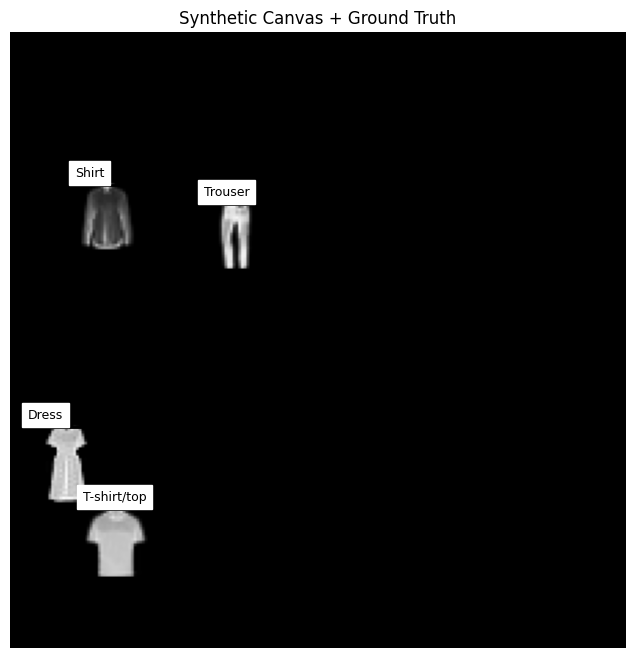

In [11]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(canvas,cmap="gray")

for box, label in zip(boxes,labels):
    x1, y1, x2, y2 = box
    
    rectangle = plt.Rectangle((x1, y1), x2 - x1, y2 - y1,fill=False,linewidth=2)
    ax.add_patch(rectangle)
    ax.text( x1, max(0, y1 - 3), CLASS_NAMES[label],fontsize=9,backgroundcolor="white")

ax.set_title("Synthetic Canvas + Ground Truth")
ax.axis("off")
plt.show()

converts the ground-truth bounding boxes and class labels into a 7×7 grid format that the CNN can learn to predict. It first creates three target arrays: objectness to indicate whether a grid cell contains an object, box targets to store the object’s center position (x_offset, y_offset) and its normalized width and height, and class targets to store the object’s class. For each object, it calculates the center of its bounding box, finds which grid cell contains that center, calculates where the center lies within that cell, normalizes the box width and height, and stores all this information in that cell along with the class label. Finally, it returns these three target arrays, which become the ground truth used to train the detector.

In [12]:
def encode_targets(boxes,labels):

    objectness = np.zeros((GRID_SIZE, GRID_SIZE),dtype=np.float32)
    box_targets = np.zeros((GRID_SIZE, GRID_SIZE, 4), dtype=np.float32)
    class_targets = np.zeros( (GRID_SIZE, GRID_SIZE), dtype=np.int64)
    
    cell_size = (CANVAS_SIZE / GRID_SIZE)

    for box, label in zip( boxes, labels):
        x1, y1, x2, y2 = box
        
        cx = ( x1 + x2 ) / 2.0
        cy = (y1 + y2) / 2.0
        
        col = int(cx / cell_size )
        row = int(cy / cell_size)

        col = min(GRID_SIZE - 1,max(0, col))
        row = min(GRID_SIZE - 1,max(0, row))

        cell_x = col * cell_size
        cell_y = row * cell_size

        x_offset = (cx - cell_x) / cell_size
        y_offset = (cy - cell_y) / cell_size

        width = (x2 - x1) / CANVAS_SIZE
        height = (y2 - y1) / CANVAS_SIZE

        objectness[row,col] = 1.0
        box_targets[row,col] = [x_offset,y_offset,width,height]
        class_targets[row,col] = label

    return (objectness,box_targets,class_targets)

In [13]:
objectness, box_targets, class_targets = (encode_targets(boxes,labels))
print("Occupied grid cells:")
for row in range(GRID_SIZE):
    for col in range(GRID_SIZE):
        if objectness[row, col] == 1:
            print(f"Cell ({row}, {col})")
            print("  Box target:",box_targets[row, col])
            print( "  Class:",CLASS_NAMES[class_targets[row, col]])

Occupied grid cells:
Cell (2, 1)
  Box target: [0.09375    0.09375    0.10714286 0.10714286]
  Class: Shirt
Cell (2, 2)
  Box target: [0.5625     0.3125     0.10714286 0.10714286]
  Class: Trouser
Cell (4, 0)
  Box target: [0.625   0.90625 0.125   0.125  ]
  Class: Dress
Cell (5, 1)
  Box target: [0.203125   0.796875   0.11160714 0.11160714]
  Class: T-shirt/top


creates a PyTorch dataset specifically for our object detection model. It takes the original Fashion-MNIST dataset and, whenever an item is requested, generates a new synthetic 224×224 image containing multiple Fashion-MNIST objects, then uses encode_targets() to convert their bounding boxes and labels into the objectness, box, and class target arrays. It then converts the image and these targets from NumPy arrays into PyTorch tensors, normalizes the image pixels from 0–255 to 0–1, and adds the single grayscale channel dimension required by the CNN. Finally, it returns the image plus its three corresponding ground-truth targets, which the model uses during training.

In [14]:
class SyntheticFashionDetectionDataset(Dataset):
    def __init__(self,fashion_dataset, num_samples):
        self.fashion_dataset = (fashion_dataset)
        self.num_samples = (num_samples)

    def __len__(self):
        return self.num_samples

    def __getitem__(self, index):
        canvas, boxes, labels = (generate_synthetic_sample(self.fashion_dataset))
        (objectness,box_targets,class_targets) = encode_targets(boxes,labels)
        
        image = (torch.from_numpy(canvas).float()/ 255.0)
        image = image.unsqueeze(0)
        
        objectness = torch.from_numpy(objectness)
        box_targets = torch.from_numpy(box_targets)
        class_targets = torch.from_numpy(class_targets)

        return (image,objectness,box_targets,class_targets)

In [15]:
train_detection_dataset = (SyntheticFashionDetectionDataset(fashion_train,TRAIN_SAMPLES))
val_detection_dataset = (SyntheticFashionDetectionDataset(fashion_test,VAL_SAMPLES))

print("Training samples:",len(train_detection_dataset))
print("Validation samples:",len(val_detection_dataset))

Training samples: 10000
Validation samples: 2000


In [43]:
train_loader = DataLoader(
    train_detection_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_detection_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

CNN designed to detect multiple objects on a 224×224 image. It has 5 convolutional layers. After every convolution, Batch Normalization is used to keep the values flowing through the network more stable and help training, while ReLU is used as the activation function to introduce non-linearity so the network can learn more complicated patterns rather than just simple relationships. 

In [18]:
class FashionDetectionCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = nn.Sequential(
            nn.Conv2d(1,32,kernel_size=3,stride=2,padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.Conv2d(32,64,kernel_size=3,stride=2,padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            
            nn.Conv2d(64,128,kernel_size=3,stride=2,padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            
            nn.Conv2d(128,256,kernel_size=3,stride=2,padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            nn.Conv2d(256,256,kernel_size=3,stride=2,padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True)
        )
        
        self.detection_head = nn.Conv2d(256,OUTPUT_SIZE,kernel_size=1)

    def forward(self, x):
        features = self.backbone(x)
        predictions = self.detection_head(features)
        predictions = predictions.permute(0,2,3,1)

        return predictions

In [19]:
model = FashionDetectionCNN().to(DEVICE)
print(model)

FashionDetectionCNN(
  (backbone): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (10): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): 

We use three different loss functions because the model has three different jobs: BCEWithLogitsLoss is used for objectness because it is a binary decision (object vs. no object), SmoothL1Loss is used for bounding-box regression because it measures errors in the continuous values for x, y, width, and height while being less sensitive to large errors, and CrossEntropyLoss is used for classification because the model must choose one class from the 10 classes.

In [21]:
objectness_loss_fn = ( nn.BCEWithLogitsLoss())
box_loss_fn = (nn.SmoothL1Loss())
classification_loss_fn = (nn.CrossEntropyLoss())

calculates how wrong the CNN's predictions are overall by calculating three separate losses. It then calculates the objectness loss for all grid cells but only calculates the box and classification losses for cells that actually contain an object, using the object_mask. If there are no objects, those two losses are set to zero. then it combines the three losses into one total loss, with the box and classification losses multiplied by their respective weights, and returns the total loss along with each individual loss so they can be monitored during training.

In [22]:
def detection_loss(predictions,objectness_target,box_target,class_target):
    objectness_logits = (predictions[..., 0])
    box_predictions = (predictions[..., 1:5])
    class_logits = (predictions[..., 5:])

    objectness_loss = (objectness_loss_fn(objectness_logits,objectness_target))
    object_mask = (objectness_target > 0.5)
    if object_mask.any():
        box_loss = box_loss_fn(box_predictions[object_mask],box_target[object_mask])
        classification_loss = (classification_loss_fn(class_logits[object_mask],class_target[object_mask]))

    else:
        box_loss = torch.tensor(0.0, device=predictions.device)
        classification_loss = torch.tensor(0.0, device=predictions.device)

    total_loss = (objectness_loss + BOX_LOSS_WEIGHT * box_loss + CLASS_LOSS_WEIGHT * classification_loss)
    
    return (total_loss,objectness_loss,box_loss,classification_loss)

used the Adam optimizer because it is a good general-purpose optimizer for training CNNs and is relatively easy to train with. Adam automatically adjusts the learning rate for each model parameter using information from previous gradients, which can make training faster and more stable than basic gradient descent. 

In [24]:
optimizer = torch.optim.Adam(model.parameters(),lr=LEARNING_RATE)

converts the predicted normalized width and height into pixels, then uses the grid cell's row and column plus the predicted offsets to find the object's center. From that center and the predicted width and height, it calculates the four corners of the box: x1, y1, x2, y2. Finally, it clips the coordinates so the predicted box cannot go outside the 224×224 image.

In [25]:
def decode_box(row,col, box_prediction):
    cell_size = ( CANVAS_SIZE / GRID_SIZE)

    x_offset = float(box_prediction[0])
    y_offset = float(box_prediction[1])

    width = ( float(box_prediction[2])* CANVAS_SIZE)
    height = (float(box_prediction[3])* CANVAS_SIZE)
    
    cx = (col + x_offset) * cell_size
    cy = (row + y_offset) * cell_size
    
    x1 = cx - width / 2
    y1 = cy - height / 2
    x2 = cx + width / 2
    y2 = cy + height / 2

    x1 = max( 0,min(CANVAS_SIZE, x1))
    y1 = max( 0,min(CANVAS_SIZE, y1))
    x2 = max( 0,min(CANVAS_SIZE, x2))
    y2 = max(0,min(CANVAS_SIZE, y2))

    return [x1,y1,x2,y2]

performs one complete round of training for the CNN using all the batches in train_loader. It first puts the model into training mode and creates counters to track the total, objectness, box, and classification losses. For each batch, it moves the images and their ground-truth targets to the correct device, passes the images through the model to get predictions, and uses detection_loss() to calculate how wrong those predictions are. Then, optimizer.zero_grad() clears the previous gradients, loss.backward() calculates how the model's weights should change, and optimizer.step() updates the weights using Adam. The individual losses are accumulated throughout the epoch, and at the end they are divided by the number of batches to calculate the average loss for that epoch. Finally, the function returns the total loss and the three individual losses so we can monitor how the model is learning.

In [27]:
def train_one_epoch():

    model.train()

    total_loss = 0
    total_objectness_loss = 0
    total_box_loss = 0
    total_classification_loss = 0

    for (images,objectness_target,box_target,class_target) in train_loader:

        images = images.to(DEVICE)

        objectness_target = (objectness_target.to(DEVICE))
        box_target = (box_target.to(DEVICE))
        class_target = (class_target.to(DEVICE))

        predictions = model(images)
        (loss,objectness_loss,box_loss,classification_loss) = detection_loss(predictions,objectness_target,box_target,class_target)

     
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_objectness_loss += (objectness_loss.item())
        total_box_loss += (box_loss.item())
        total_classification_loss += (classification_loss.item())

    n = len(train_loader)

    return {"loss": total_loss / n, "objectness_loss": total_objectness_loss / n, "box_loss":total_box_loss / n,"classification_loss": total_classification_loss / n}

checks how well the trained model performs on the validation data without updating the model's weights. It first puts the model into evaluation mode and disables gradient calculations because we are only testing. For each validation batch, it gets the model's predictions and calculates the loss, then uses sigmoid to turn objectness logits into probabilities and checks which grid cells correctly detect an object. It uses softmax on the class logits to choose the predicted class and compares it with the true class. For every real object, it decodes both the predicted and true bounding boxes and calculates IoU to measure how accurately the object was localized. It then keeps track of several metrics: overall loss, objectness accuracy, classification accuracy, object recall, mean IoU, and overall detection accuracy. Finally, it averages these measurements across the validation batches and returns them so we can see how well the model performs on data it wasn't trained on.

In [28]:
def validate():

    model.eval()
    total_loss = 0
    total_objects = 0
    correct_classes = 0
    detected_objects = 0
    correct_detections = 0

    total_iou = 0
    iou_count = 0

    total_cells = 0
    correct_objectness = 0

    with torch.no_grad():

        for (images,objectness_target,box_target,class_target) in val_loader:

            images = images.to(DEVICE)
            objectness_target = (objectness_target.to(DEVICE))
            box_target = (box_target.to(DEVICE))

            class_target = (class_target.to(DEVICE))

            predictions = model(images)

            (loss,objectness_loss,box_loss,classification_loss) = detection_loss(predictions,objectness_target,box_target,class_target)

            total_loss += loss.item()
            objectness_probs = torch.sigmoid(predictions[..., 0])
            predicted_objectness = (objectness_probs >= OBJECTNESS_THRESHOLD)

            true_objectness = (objectness_target > 0.5)

            correct_objectness += (predicted_objectness == true_objectness).sum().item()
            total_cells += (true_objectness.numel())

            class_logits = (predictions[..., 5:])
            class_probabilities = (torch.softmax(class_logits,dim=-1))
            predicted_classes = (class_probabilities.argmax(dim=-1))
            object_mask = (objectness_target > 0.5)

            correct_classes += (predicted_classes[object_mask]==class_target[object_mask]).sum().item()
            total_objects += (object_mask.sum().item())
            detected_objects += (predicted_objectness[object_mask]).sum().item()


            batch_size = images.shape[0]

            for b in range(batch_size):
                positions = torch.nonzero(object_mask[b],as_tuple=False)

                for position in positions:
                    row = position[0].item()
                    col = position[1].item()

                    predicted_box = decode_box(row,col,predictions[b,row,col,1:5])
                    true_box = decode_box(row,col,box_target[b,row,col])

                    current_iou = calculate_iou(predicted_box,true_box)
                    total_iou += current_iou
                    iou_count += 1


                    correct_object = (predicted_objectness[b,row,col].item())
                    correct_class = (predicted_classes[b,row,col].item()==class_target[b,row,col].item())

                    good_iou = (current_iou >= IOU_THRESHOLD)

                    if (correct_object and correct_class and good_iou ):
                        correct_detections += 1

    n = len(val_loader)

    return {"loss": total_loss / n,
        "objectness_accuracy": correct_objectness / total_cells,
        "classification_accuracy": correct_classes / total_objects,
        "object_recall":detected_objects / total_objects,
        "mean_iou":total_iou / iou_count,
        "detection_accuracy":correct_detections / total_objects}

controls the overall training process across multiple epochs and keeps track of how the model performs over time. First, history creates empty lists to store the training loss and all the validation metrics. Then, for every epoch, the model is trained using train_one_epoch() and evaluated using validate(). The resulting values are added to the corresponding lists in history, so we can later plot things like training vs. validation loss and accuracy over the epochs. Finally, it prints the results for each epoch, including training loss, validation loss, objectness accuracy, classification accuracy, object recall, mean IoU, and overall detection accuracy, with the percentage-based metrics converted into readable percentages.

In [29]:
history = {
    "train_loss": [],
    "val_loss": [],
    "objectness_accuracy": [],
    "classification_accuracy": [],
    "object_recall": [],
    "mean_iou": [],
    "detection_accuracy": []
}


for epoch in range(EPOCHS):

    train_metrics = train_one_epoch()
    val_metrics = validate()

    history["train_loss"].append(train_metrics["loss"])
    history["val_loss"].append( val_metrics["loss"])
    history["objectness_accuracy"].append(val_metrics["objectness_accuracy"])
    history["classification_accuracy"].append(val_metrics["classification_accuracy"])
    history["object_recall"].append(val_metrics["object_recall"])
    history["mean_iou"].append(val_metrics["mean_iou"])
    history["detection_accuracy"].append(val_metrics["detection_accuracy"])

    print( f"Epoch {epoch + 1}/{EPOCHS}")
    print(f"Train Loss: "f"{train_metrics['loss']:.4f}")
    print(f"Validation Loss: "f"{val_metrics['loss']:.4f}")
    print()
    print(f"Objectness Accuracy: " f"{val_metrics['objectness_accuracy'] * 100:.2f}%")
    print(f"Classification Accuracy: "f"{val_metrics['classification_accuracy'] * 100:.2f}%")
    print(f"Object Recall: "f"{val_metrics['object_recall'] * 100:.2f}%")
    print(f"Mean IoU: "f"{val_metrics['mean_iou']:.4f}")
    print(f"Detection Accuracy: "f"{val_metrics['detection_accuracy'] * 100:.2f}%")


Epoch 1/15
Train Loss: 1.7060
Validation Loss: 1.2661

Objectness Accuracy: 98.31%
Classification Accuracy: 54.59%
Object Recall: 86.36%
Mean IoU: 0.4105
Detection Accuracy: 16.29%

Epoch 2/15
Train Loss: 0.9270
Validation Loss: 0.8568

Objectness Accuracy: 98.83%
Classification Accuracy: 68.88%
Object Recall: 89.81%
Mean IoU: 0.5138
Detection Accuracy: 36.97%

Epoch 3/15
Train Loss: 0.7880
Validation Loss: 0.7993

Objectness Accuracy: 98.85%
Classification Accuracy: 71.79%
Object Recall: 91.04%
Mean IoU: 0.5169
Detection Accuracy: 36.95%

Epoch 4/15
Train Loss: 0.7105
Validation Loss: 0.9673

Objectness Accuracy: 98.53%
Classification Accuracy: 69.92%
Object Recall: 94.98%
Mean IoU: 0.4405
Detection Accuracy: 29.84%

Epoch 5/15
Train Loss: 0.6629
Validation Loss: 1.7990

Objectness Accuracy: 15.80%
Classification Accuracy: 69.81%
Object Recall: 99.02%
Mean IoU: 0.5520
Detection Accuracy: 44.95%

Epoch 6/15
Train Loss: 0.6185
Validation Loss: 0.9151

Objectness Accuracy: 98.07%
Classi

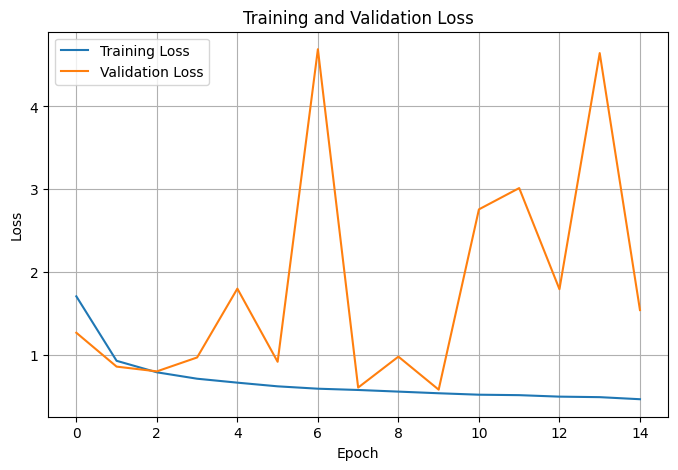

In [30]:
plt.figure(figsize=(8, 5))

plt.plot(history["train_loss"],label="Training Loss")
plt.plot(history["val_loss"],label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Training and Validation Loss")
plt.legend()
plt.grid()

plt.show()

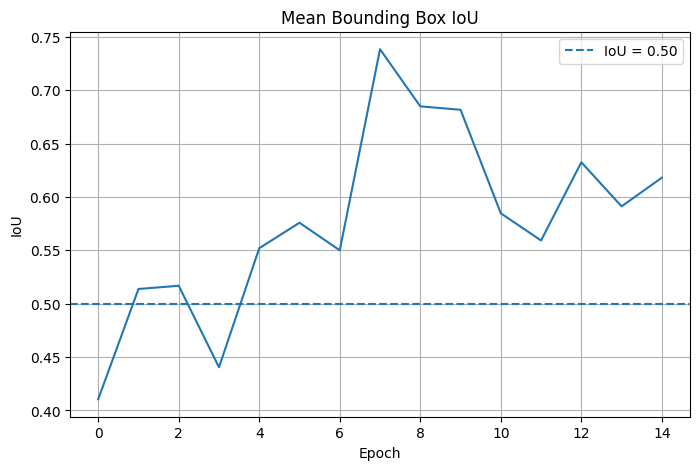

In [31]:
plt.figure(figsize=(8, 5))

plt.plot(history["mean_iou"])
plt.axhline(IOU_THRESHOLD,linestyle="--", label="IoU = 0.50")

plt.xlabel("Epoch")
plt.ylabel("IoU")

plt.title("Mean Bounding Box IoU")

plt.legend()
plt.grid()
plt.show()

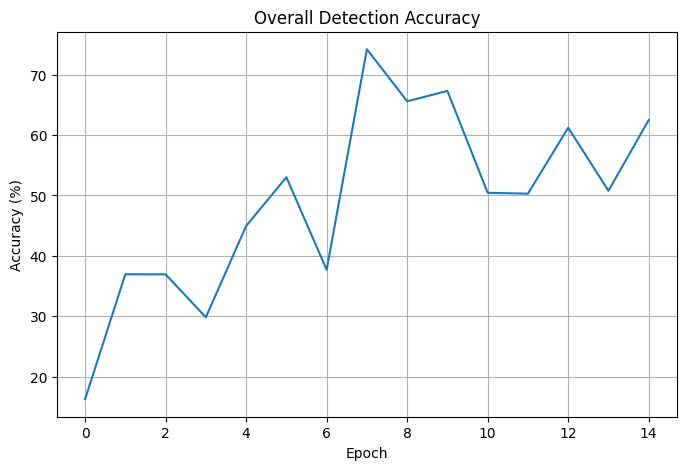

In [32]:
plt.figure(figsize=(8, 5))

plt.plot( np.array( history["detection_accuracy"] ) * 100)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")

plt.title( "Overall Detection Accuracy")
plt.grid()
plt.show()

It puts the model into evaluation mode, converts the 224×224 NumPy image into a normalized PyTorch tensor with the correct batch and channel dimensions, and passes it through the trained CNN without calculating gradients. It then checks every cell of the 7×7 grid, using sigmoid to get the probability that an object exists and softmax to determine which of the 10 classes is most likely. These two probabilities are multiplied to produce an overall confidence score. If the confidence is below the chosen threshold, that prediction is ignored; otherwise, decode_box() converts the predicted box values back into actual image coordinates. Finally, the function stores the detected bounding box, class ID, class name, and confidence in a list and returns all the detections.

In [33]:
def detect_objects(model,canvas,confidence_threshold=DETECTION_CONFIDENCE_THRESHOLD):

    model.eval()
    image = (torch.from_numpy(canvas).float()/ 255.0)
    image = image.unsqueeze(0)
    image = image.unsqueeze(0)
    image = image.to(DEVICE)

    with torch.no_grad():
        predictions = model(image)

    predictions = predictions[0]
    detections = []
    
    for row in range(GRID_SIZE):
        for col in range(GRID_SIZE):
            prediction = (predictions[row,col])
            objectness_probability = (torch.sigmoid(prediction[0]).item())

            class_logits = (prediction[5:])
            class_probabilities = (torch.softmax(class_logits,dim=0))
            class_probability, class_id = (torch.max(class_probabilities,dim=0))

            class_probability = (class_probability.item())
            class_id = (class_id.item())
            
            confidence = (objectness_probability * class_probability)

            if (confidence < confidence_threshold):
                continue

            box = decode_box(row,col,prediction[1:5])

            detections.append({
                    "box": box,
                    "class_id": class_id,
                    "class_name":CLASS_NAMES[class_id],
                    "confidence":confidence
            })

    return detections

In [35]:
def visualize_predictions(canvas,detections,title="Model Predictions"):

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(canvas,cmap="gray")

    for detection in detections:
        x1, y1, x2, y2 = (detection["box"])
        class_name = (detection["class_name"])
        confidence = (detection["confidence"])

        rectangle = plt.Rectangle((x1, y1),x2 - x1,y2 - y1,fill=False,linewidth=2)

        ax.add_patch(rectangle)
        ax.text(x1,max(0, y1 - 3),f"{class_name} "f"{confidence * 100:.1f}%",fontsize=9,backgroundcolor="white")

    ax.set_title(title)
    ax.axis("off")
    plt.tight_layout()
    plt.show()

GROUND TRUTH
Object 1:
  Box: [28, 19, 53, 44]
  Class: Trouser

Object 2:
  Box: [13, 161, 38, 186]
  Class: Coat

Object 3:
  Box: [149, 153, 173, 177]
  Class: Dress



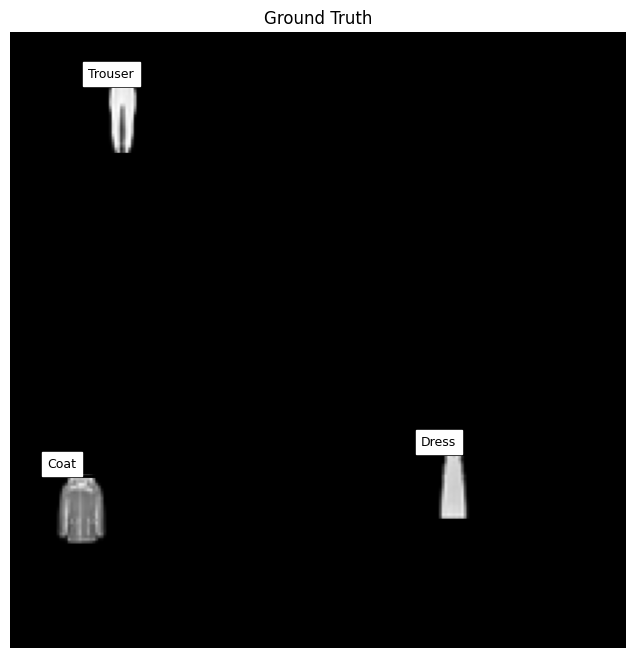

In [36]:
test_canvas, true_boxes, true_labels = (generate_synthetic_sample(fashion_test))

print("GROUND TRUTH")

for i, (box, label) in enumerate(zip(true_boxes, true_labels)):
    print(f"Object {i + 1}:")
    print(f"  Box: {box}")
    print(f"  Class: {CLASS_NAMES[label]}")
    print()


fig, ax = plt.subplots(figsize=(8, 8))

ax.imshow(test_canvas,cmap="gray")

for box, label in zip(true_boxes,true_labels):
    x1, y1, x2, y2 = box
    
    rectangle = plt.Rectangle((x1, y1),x2 - x1, y2 - y1,fill=False,linewidth=2 )

    ax.add_patch(rectangle)
    ax.text( x1,max(0, y1 - 3),CLASS_NAMES[label],fontsize=9, backgroundcolor="white")

ax.set_title("Ground Truth")
ax.axis("off")
plt.show()

In [37]:
detections = detect_objects(model,test_canvas)

if len(detections) == 0:
    print("No objects detected.")

else:
    for i, detection in enumerate(detections):
        print(f"Object {i + 1}:")
        print( f"  Box: "f"{[round(x, 1) for x in detection['box']]}")
        print( f"  Class: "f"{detection['class_name']}")
        print(f"  Confidence: "f"{detection['confidence'] * 100:.2f}%")



MODEL PREDICTIONS
Object 1:
  Box: [29.5, 10.1, 53.7, 34.4]
  Class: Trouser
  Confidence: 92.76%

Object 2:
  Box: [26.1, 18.2, 51.6, 45.6]
  Class: Trouser
  Confidence: 88.01%

Object 3:
  Box: [12.9, 160.2, 37.3, 185.2]
  Class: Coat
  Confidence: 70.74%

Object 4:
  Box: [151.7, 149.9, 174.2, 173.8]
  Class: Dress
  Confidence: 98.35%



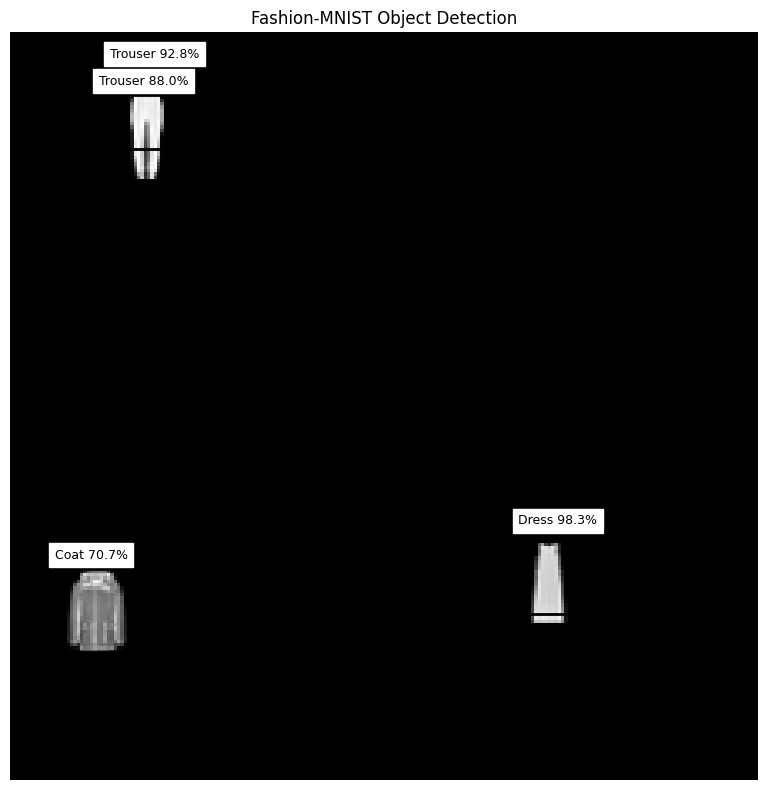

In [38]:
visualize_predictions(test_canvas,detections,title="Fashion-MNIST Object Detection")